## Initial EDA on event dataset (Ticketmaster)

In [4]:
import pandas as pd
import duckdb
# import data from csv-file
df = pd.read_csv("../api/events_full_year.csv")

df

,event_id,name,url,image_url,date,time,status,segment,genre,subgenre,venue_name,venue_city,venue_address,venue_lat,venue_lon,day_of_week,month_name,month_num,year,hour
0,Z698xZq2Z1k-Fudb3,Svartklubben - Mat & Musik i Mörker,https://www.ticketmaster.se/event/svartklubben...,https://s1.ticketm.net/dam/a/841/1c1b2a57-616a...,2026-04-14,18:00,onsale,Miscellaneous,Food & Drink,Restaurant,Svartklubben,Stockholm,Södermannagatan 27,59.31209,18.08133,Tuesday,April,4,2026,18
1,Z698xZq2Z1k37ef-A,Eric Idle,https://www.ticketmaster.se/event/eric-idle-al...,https://s1.ticketm.net/dam/e/d88/0cbf49c5-f18e...,2026-04-14,19:00,onsale,Arts & Theatre,Theatre,Miscellaneous,Cirkus,Stockholm,Djurgårdsslätten 43-45,59.32457,18.09969,Tuesday,April,4,2026,19
2,Z698xZq2Z16vZ0G9_M,40 Fingers,https://www.ticketmaster.se/event/40-fingers-b...,https://s1.ticketm.net/dam/e/a38/c01c9483-250c...,2026-04-15,19:30,onsale,Music,Rock,Pop,Göta Lejon,Stockholm,Götgatan 55,59.31378,18.07384,Wednesday,April,4,2026,19
3,Z698xZq2Z16vavQaZx,Amanda Bergman,https://www.ticketmaster.se/event/amanda-bergm...,https://s1.ticketm.net/dam/a/da1/c489a12c-bab8...,2026-04-15,19:30,onsale,Music,Alternative,Indie Pop,Cirkus,Stockholm,Djurgårdsslätten 43-45,59.32457,18.09969,Wednesday,April,4,2026,19
4,Z698xZq2Z16va-0gjy,Svartklubben - Mat & Musik i Mörker,https://www.ticketmaster.se/event/svartklubben...,https://s1.ticketm.net/dam/a/841/1c1b2a57-616a...,2026-04-16,18:00,onsale,Arts & Theatre,Theatre,Miscellaneous,Svartklubben,Stockholm,Södermannagatan 27,59.31209,18.08133,Thursday,April,4,2026,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
628,Z698xZq2Z1kkFuy7I,NANNE GRÖNVALLS JUBILEUMSTURNÈ - HÄR ÄR JAG,https://www.ticketmaster.se/event/nanne-gronva...,https://s1.ticketm.net/dam/e/385/3cee7fea-6fb8...,2027-04-18,18:00,rescheduled,Music,Other,Other,Cirkus,Stockholm,Djurgårdsslätten 43-45,59.32457,18.09969,Sunday,April,4,2027,18
629,Z698xZq2Z16vkd0spo,Fredrik Andersson - TOO SOON,https://www.ticketmaster.se/event/fredrik-ande...,https://s1.ticketm.net/dam/a/58b/088437d8-99d3...,2027-04-23,19:00,onsale,Arts & Theatre,Comedy,Comedy,Nya Cirkus,Stockholm,Djurgårdsslätten 43-45,59.32458,18.09970,Friday,April,4,2027,19
630,Z698xZq2Z16evgf6fd,Babblarna & Klonks Klapp-kalas - 2027,https://www.ticketmaster.se/event/babblarna--k...,https://s1.ticketm.net/dam/a/2fe/0e037444-3367...,2027-05-02,14:00,onsale,Arts & Theatre,Children's Theatre,Children's Theatre,Nya Cirkus,Stockholm,Djurgårdsslätten 43-45,59.32458,18.09970,Sunday,May,5,2027,14
631,Z698xZq2Z1k00fOqN,Fredrik Andersson - TOO SOON,https://www.ticketmaster.se/event/fredrik-ande...,https://s1.ticketm.net/dam/a/58b/088437d8-99d3...,2027-05-14,19:00,onsale,Arts & Theatre,Comedy,Comedy,Cirkus,Stockholm,Djurgårdsslätten 43-45,59.32457,18.09969,Friday,May,5,2027,19


In [17]:
df.head()

,event_id,name,url,image_url,date,time,status,segment,genre,subgenre,venue_name,venue_city,venue_address,venue_lat,venue_lon,day_of_week,month_name,month_num,year,hour
0,Z698xZq2Z16vAkOybO,Labero's Magic World,https://www.ticketmaster.se/event/laberos-magi...,https://s1.ticketm.net/dam/a/f00/7a24bdb3-8f78...,2026-04-11,18:00:00,onsale,Miscellaneous,Food & Drink,Food & Drink,La Botanica,Stockholm,Tel: 08-751 09 65 - Stjärntorget 2,59.368980,18.005850,Saturday,April,4,2026,18
1,Z698xZq2Z16vQo0Eox,Svartklubben - Mat & Musik i Mörker,https://www.ticketmaster.se/event/svartklubben...,https://s1.ticketm.net/dam/a/841/1c1b2a57-616a...,2026-04-11,18:00:00,onsale,Arts & Theatre,Theatre,Miscellaneous,Svartklubben,Stockholm,Södermannagatan 27,59.312090,18.081330,Saturday,April,4,2026,18
2,Z698xZq2Z16vF3k9G0,MAMMA MIA! THE PARTY,https://www.ticketmaster.se/event/mamma-mia-th...,https://s1.ticketm.net/dam/e/d78/e055a3c6-df72...,2026-04-11,19:30:00,onsale,Arts & Theatre,Theatre,Miscellaneous,Tyrol,Stockholm,Lilla Allmänna Gränd 2,59.324127,18.096259,Saturday,April,4,2026,19
3,Z698xZq2Z1k-Skb4F,Bo Kaspers Orkester - Il magnifico,https://www.ticketmaster.se/event/bo-kaspers-o...,https://s1.ticketm.net/dam/e/9f5/189e04cc-d86d...,2026-04-11,19:30:00,onsale,Music,Rock,Pop,Göta Lejon,Stockholm,Götgatan 55,59.313780,18.073840,Saturday,April,4,2026,19
4,Z698xZq2Z1k_y_Mo_,& Julia,https://www.ticketmaster.se/event/-julia-bilje...,https://s1.ticketm.net/dam/a/9d5/39c257d4-fad5...,2026-04-11,19:30:00,onsale,Arts & Theatre,Theatre,Miscellaneous,Cirkus,Stockholm,Djurgårdsslätten 43-45,59.324570,18.099690,Saturday,April,4,2026,19


In [18]:
# check RangeIndex & non-null
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 635 entries, 0 to 634
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_id       635 non-null    str    
 1   name           635 non-null    str    
 2   url            635 non-null    str    
 3   image_url      635 non-null    str    
 4   date           635 non-null    str    
 5   time           635 non-null    str    
 6   status         635 non-null    str    
 7   segment        635 non-null    str    
 8   genre          635 non-null    str    
 9   subgenre       635 non-null    str    
 10  venue_name     635 non-null    str    
 11  venue_city     635 non-null    str    
 12  venue_address  633 non-null    str    
 13  venue_lat      635 non-null    float64
 14  venue_lon      635 non-null    float64
 15  day_of_week    635 non-null    str    
 16  month_name     635 non-null    str    
 17  month_num      635 non-null    int64  
 18  year           635 no

In [19]:
df.columns

Index(['event_id', 'name', 'url', 'image_url', 'date', 'time', 'status',
       'segment', 'genre', 'subgenre', 'venue_name', 'venue_city',
       'venue_address', 'venue_lat', 'venue_lon', 'day_of_week', 'month_name',
       'month_num', 'year', 'hour'],
      dtype='str')

In [20]:
# descriptive statistics of summative statistics (only numerical columns)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
venue_lat,635.0,59.380313,0.183879,59.29045,59.31378,59.32457,59.33623,59.99333
venue_lon,635.0,18.141746,0.225299,18.00041,18.06386,18.08133,18.09969,18.89062
month_num,635.0,7.168504,2.979152,1.00000,5.00000,6.00000,10.00000,12.00000
year,635.0,2026.042520,0.201931,2026.00000,2026.00000,2026.00000,2026.00000,2027.00000
hour,635.0,17.919685,2.808534,0.00000,18.00000,19.00000,19.00000,22.00000


In [21]:
# check number of rows and columns
print(f"Rows: {df.shape[0]}, Cols: {df.shape[1]}")

Rows: 635, Cols: 20


In [22]:
import duckdb

df["segment"].value_counts()

segment
Arts & Theatre    426
Music             152
Miscellaneous      53
Sports              4
Name: count, dtype: int64

In [23]:
df["genre"].value_counts()

genre
Theatre                    233
Comedy                      95
Dance                       63
Rock                        59
Other                       37
Food & Drink                31
Family                      19
Hip-Hop/Rap                 19
Spectacular                 12
Magic & Illusion            11
Dance/Electronic            10
Classical                    7
Alternative                  5
Folk                         5
Children's Theatre           5
World                        4
Blues                        3
Fairs & Festivals            3
Miscellaneous                3
Latin                        3
Metal                        2
Soccer                       2
Martial Arts                 1
Reggae                       1
R&B                          1
Circus & Specialty Acts      1
Name: count, dtype: int64

In [24]:
# how many different events do we have?
duckdb.sql("""--sql
SELECT
DISTINCT(name)
FROM df
""")

┌─────────────────────────────────────────────────────────────────────────────┐
│                                    name                                     │
│                                   varchar                                   │
├─────────────────────────────────────────────────────────────────────────────┤
│ Bo Kaspers Orkester - Il magnifico                                          │
│ Happy Voices under ledning av Gabriel Forss. Gäst: Linnea Henriksson        │
│ Cherrie                                                                     │
│ Kungliga Svenska Balettskolan - Jaunty                                      │
│ Pitbull – I’m Back! , Platinum Tickets                                      │
│ The Weeknd: After Hours Til Dawn Tour | Strawberry Arena Premium Experience │
│ MAFFIA COMEDY SUPERWEEKEND med Shanthi Rydwall Menon m.fl                   │
│ Torka aldrig tårar utan handskar                                            │
│ Efva Lilja - A Life as Right as Rain  

In [25]:
# how many, and which events is there a specific date
# using Window functions OVER() to aggregate over the full result set
result = duckdb.sql("""
    SELECT
        name,
        date,
        COUNT(*) OVER() AS total_events
    FROM df
    WHERE date = '2026-04-22'
""").df()

print(result.to_string(index=False))

                                                                name       date  total_events
                       GöteborgsOperans Danskompani - Little Concert 2026-04-22             5
                             Svartklubben - Mat och standup i mörker 2026-04-22             5
                           Sissela Kyle "Min Föreställning Om Mamma" 2026-04-22             5
Scott Bradlee’s Postmodern Jukebox - The Future Is Vintage Tour 2026 2026-04-22             5
                                                    Medborgare Nûjen 2026-04-22             5


In [26]:
# which days has most events?
duckdb.sql("""
SELECT
    date,
    COUNT(*) AS num_events
    FROM df
    GROUP BY date
    ORDER BY num_events DESC
    LIMIT 5
""")

┌────────────┬────────────┐
│    date    │ num_events │
│  varchar   │   int64    │
├────────────┼────────────┤
│ 2026-04-25 │         18 │
│ 2026-04-18 │         17 │
│ 2026-05-09 │         15 │
│ 2026-04-24 │         12 │
│ 2026-05-02 │         12 │
└────────────┴────────────┘

In [27]:
# which event has the most nr of shows?
duckdb.sql("""
SELECT
    name,
    COUNT(*) AS num_shows
    FROM df
    GROUP BY name
    ORDER BY num_shows DESC
    LIMIT 5
""")

┌────────────────────────────────────────┬───────────┐
│                  name                  │ num_shows │
│                varchar                 │   int64   │
├────────────────────────────────────────┼───────────┤
│ MAMMA MIA! THE PARTY                   │        89 │
│ Torka aldrig tårar utan handskar       │        52 │
│ Svartklubben - Mat & Musik i Mörker    │        40 │
│ & Julia                                │        36 │
│ Fredrik ”Benke” Rydman – Romeo & Julia │        18 │
└────────────────────────────────────────┴───────────┘

In [5]:
# which venue has most events booked this weekend? (week 16)
duckdb.sql("""
SELECT
    venue_name AS venue,
    date,
    name AS event_name,
    COUNT(*) AS num_events
    FROM df
    WHERE date BETWEEN '2026-04-17' AND '2026-04-19'
    GROUP BY venue, date, event_name
    ORDER BY num_events DESC
    LIMIT 5
""")

┌────────────────────────┬────────────┬────────────────────────────────────┬────────────┐
│         venue          │    date    │             event_name             │ num_events │
│        varchar         │  varchar   │              varchar               │   int64    │
├────────────────────────┼────────────┼────────────────────────────────────┼────────────┤
│ Rival                  │ 2026-04-18 │ Per Andersson - Kardborreshowen    │          2 │
│ Tyrol                  │ 2026-04-18 │ MAMMA MIA! THE PARTY               │          2 │
│ Göta Lejon             │ 2026-04-18 │ Bo Kaspers Orkester - Il magnifico │          2 │
│ Dansens Hus Studioscen │ 2026-04-18 │ Claire Parsons - Puder             │          2 │
│ Cirkus                 │ 2026-04-18 │ & Julia                            │          2 │
└────────────────────────┴────────────┴────────────────────────────────────┴────────────┘

## Visualizations

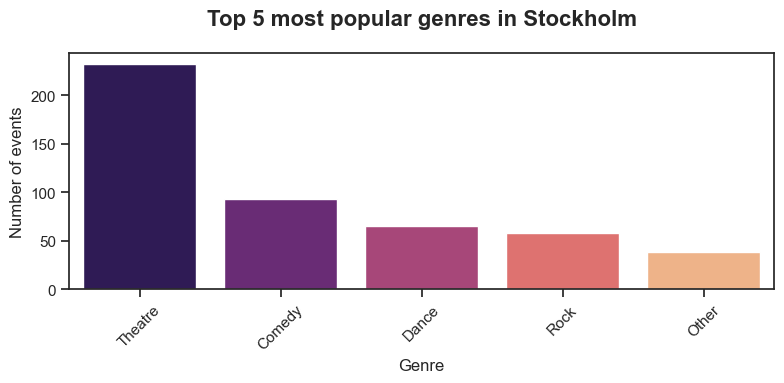

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

""" --- 5 Most Popular Genre --- """

# 1. Calculation using DuckDB
result_top_genres = duckdb.sql("""
    SELECT
        genre,
        COUNT(*) AS event_count
    FROM df
    WHERE genre IS NOT NULL
    GROUP BY genre
    ORDER BY event_count DESC
    LIMIT 5
""")

# 2. Convert result to DataFrame
top_genres = result_top_genres.df()

# 3. Choose a theme
sns.set_theme(style="ticks")

# 3. Create graph
plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=top_genres,
    x="genre",
    y="event_count",
    palette="magma", # colorpalette
    hue="genre",     # Gives every row a unique color
    legend=False
)

# 4. Data Storytelling: Clear titles and labels
plt.title("Top 5 most popular genres in Stockholm", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Number of events", fontsize=12)

# Rotate text on x-axis
plt.xticks(rotation=45)

# 5. Save and plot
plt.tight_layout()
plt.savefig("data_images/top_genres.png", dpi=300)
plt.show()

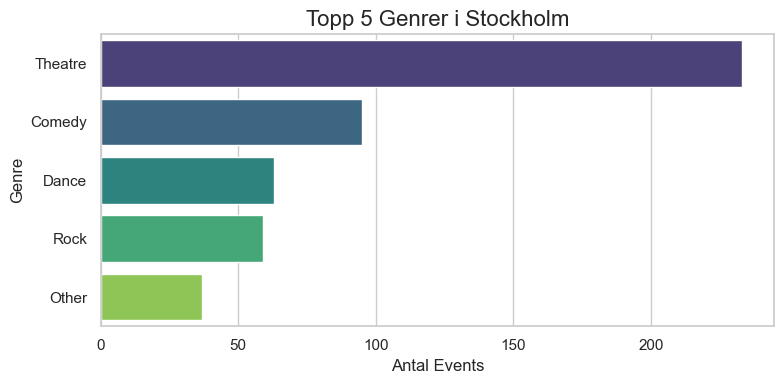

In [38]:
""" --- Number Of Events Per Genre --- """

result = duckdb.sql("""
SELECT
    genre,
    COUNT(*) AS num_events
    FROM df
    GROUP BY genre
    ORDER BY num_events DESC
    LIMIT 5
""")

plot_df = result.df()

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=plot_df,
    x="num_events",
    y="genre",
    hue="genre",
    palette="viridis",
    legend=False
)

plt.title("Topp 5 Genrer i Stockholm", fontsize=16)
plt.xlabel("Antal Events", fontsize=12)
plt.ylabel("Genre", fontsize=12)

plt.tight_layout()
plt.savefig("data_images/events_per_genre.png", dpi=300)
plt.show()

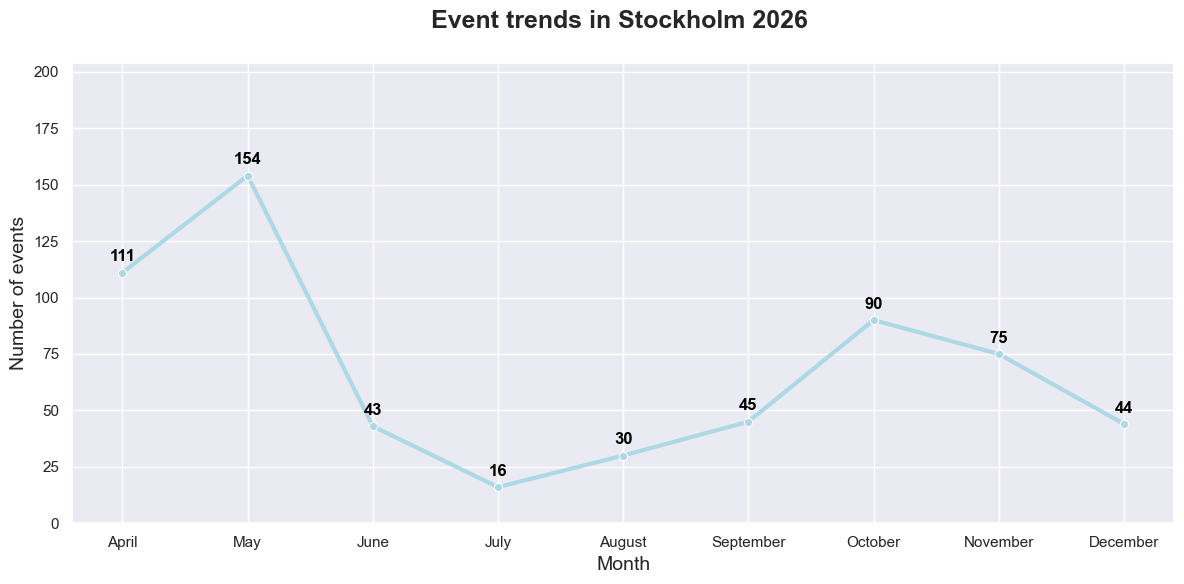

In [31]:
""" --- Number Of Events Over Time In 2026 --- """

result_monthly = duckdb.sql("""
    SELECT
        month_num,
        month_name,
        COUNT(*) AS event_count
    FROM df
    WHERE year = 2026
    GROUP BY month_num, month_name
    ORDER BY month_num
""")

monthly_data = result_monthly.df()

sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 6))

# Create linechart
ax = sns.lineplot(
    data=monthly_data,
    x='month_name',
    y='event_count',
    marker='o',
    linewidth=3,
    color='lightblue'
)

# Add values (number of events) above marks
for x, y in zip(monthly_data['month_name'], monthly_data['event_count']):
    plt.text(x, y + 5, str(y), color='black', ha="center", fontweight='bold')


plt.title('Event trends in Stockholm 2026 ', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of events', fontsize=14)
plt.ylim(0, monthly_data['event_count'].max() + 50)


plt.tight_layout()
plt.savefig("data_images/event_trends_2026.png", dpi=300)
plt.show()

# Todo:

Generera fejk data så vik kan se populära tider på museumen

Ticketmaster

- Vilka veckodagar har flest events? (bar chart)
- Vilka venues har flest events?
- Hur stor andel av events saknar pris (gratis/okänt)?
- (Vilken genre dominerar Stockholm under sommaren vs vintern)
- (Finns det "tomma" perioder utan events?)

Museer

- Fördelning av betyg (histogram)
- Antal recensioner per museum (horisontellt bar chart — bra för ranking)
- Popularity index visualiserat (bar chart sorterat)
- Gratis vs betalt — hur många av varje? (pie eller bar)
- Karta med lat/lon — storlek på punkt = popularity_index

## EDA on museums data

In [32]:
m_df = pd.read_csv("../api/stockholm_museums.csv")

m_df.head()

,name,address,lat,lon,website,rating,num_reviews,price_level,opening_hours,place_id,is_free,popularity_score,popularity_index
0,Vasamuseet,"Galärvarvsvägen 14, 115 21 Stockholm, Sverige",59.328023,18.091396,https://www.vasamuseet.se/,4.8,66909.0,NaN,måndag: 10:00–17:00 | tisdag: 10:00–17:00 | on...,ChIJrymDbVSdX0YRQTLBtPGa8M8,False,1241.6,100.0
1,Kungliga slottet,"Kungliga slottet, 107 70 Stockholm, Sverige",59.326822,18.071719,https://www.kungligaslotten.se/vara-besoksmal/...,4.5,43955.0,NaN,måndag: 10:00–16:00 | tisdag: 10:00–16:00 | on...,ChIJAUpMflidX0YRNj52SJZ6-b0,False,943.4,73.0
2,Skansen,"Djurgårdsslätten 49-51, 115 21 Stockholm, Sverige",59.326323,18.105858,https://www.skansen.se/,4.5,34488.0,NaN,måndag: 10:00–16:00 | tisdag: 10:00–16:00 | on...,ChIJN5Ta_qqCX0YRMYVG1s-2NSw,False,835.7,63.3
3,ABBA The Museum,"Djurgårdsvägen 68, 115 21 Stockholm, Sverige",59.325091,18.096781,https://www.abbathemuseum.com/,4.5,20086.0,NaN,måndag: 10:00–18:00 | tisdag: 10:00–18:00 | on...,ChIJBf9B06qCX0YRR46XNXjwFUo,False,637.8,45.3
4,Nordiska museet,"Djurgårdsvägen 6-16, 115 93 Stockholm, Sverige",59.329008,18.094268,https://www.nordiskamuseet.se/,4.3,11096.0,NaN,måndag: 10:00–17:00 | tisdag: 10:00–17:00 | on...,ChIJxagZg1OdX0YRGKnPhRyci9c,False,453.0,28.6


In [33]:
m_df.shape

(20, 13)

In [34]:
m_df.columns

Index(['name', 'address', 'lat', 'lon', 'website', 'rating', 'num_reviews',
       'price_level', 'opening_hours', 'place_id', 'is_free',
       'popularity_score', 'popularity_index'],
      dtype='str')

In [35]:
m_df["rating"].value_counts()

rating
4.5    7
4.3    4
4.4    3
4.8    2
4.6    1
4.2    1
4.1    1
Name: count, dtype: int64

In [36]:
m_df["is_free"].value_counts()


is_free
False    13
True      7
Name: count, dtype: int64

In [37]:
m_df.describe().T

,count,mean,std,min,25%,50%,75%,max
lat,20.0,59.331553,0.011875,59.317962,59.326352,59.328281,59.333085,59.368975
lon,20.0,18.083757,0.015941,18.053878,18.071516,18.084757,18.094496,18.118803
rating,19.0,4.442105,0.177375,4.100000,4.300000,4.500000,4.500000,4.800000
num_reviews,19.0,12551.000000,17543.697460,1118.000000,2030.000000,7202.000000,10174.500000,66909.000000
price_level,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity_score,19.0,417.731579,301.005408,137.100000,197.800000,366.600000,436.700000,1241.600000
popularity_index,19.0,25.405263,27.256833,0.000000,5.450000,20.800000,27.100000,100.000000


## Exploration and Visualization